## Imports and Setup


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)


## Load Data and Stock Selection


In [17]:
# Load cleaned price data
prices = pd.read_csv(
    "./dataset/cleaned_data.csv", 
    parse_dates=["Date"], 
    index_col="Date"
)

print("Loaded price data:", prices.shape)
print("Date range:", prices.index.min(), "to", prices.index.max())
print("Total stocks:", len(prices.columns))

# Load sector mapping
sector_df = pd.read_csv("./dataset/stock_sectors.csv")
stock_sectors = dict(zip(sector_df['Symbol'], sector_df['Sector']))

# Use ALL stocks for Stage 4 (ML discovery scales linearly, unlike Stage 3's pairwise tests)
selected_tickers = prices.columns.tolist()

# Use all prices (no subsetting needed)
prices_subset = prices.copy()

# Show sector breakdown
selected_sectors = [stock_sectors.get(t, 'Unknown') for t in selected_tickers]
sector_counts = pd.Series(selected_sectors).value_counts()
print("\nSector breakdown:")
for sector, count in sector_counts.items():
    print(" ", sector + ":", count, "stocks")

Loaded price data: (3905, 432)
Date range: 2010-01-04 00:00:00 to 2024-12-20 00:00:00
Total stocks: 432

Sector breakdown:
  Financials: 68 stocks
  Industrials: 62 stocks
  Healthcare: 49 stocks
  Information Technology: 47 stocks
  Consumer Discretionary: 45 stocks
  Consumer Staples: 32 stocks
  Real Estate: 29 stocks
  Utilities: 29 stocks
  Materials: 22 stocks
  Unknown: 17 stocks
  Communication Services: 16 stocks
  Energy: 16 stocks


## Compute Log Returns


In [18]:
# Compute log returns
log_returns = np.log(prices_subset / prices_subset.shift(1)).dropna()

print("Computed log returns:", log_returns.shape)
print("Date range:", log_returns.index.min(), "to", log_returns.index.max())
print("Missing values:", log_returns.isna().sum().sum())

# Handle any remaining missing values
log_returns = log_returns.fillna(method='ffill').fillna(method='bfill')

print("\nLog returns statistics:")
print(log_returns.describe().T[['mean', 'std', 'min', 'max']].head(10))


Computed log returns: (3904, 432)
Date range: 2010-01-05 00:00:00 to 2024-12-20 00:00:00
Missing values: 0

Log returns statistics:
          mean       std       min       max
GNRC  0.000640  0.026572 -0.292250  0.226264
CHTR  0.000591  0.018555 -0.180461  0.153747
MTCH  0.000449  0.025437 -0.249648  0.216437
NDAQ  0.000626  0.015586 -0.137063  0.130180
WFC   0.000242  0.018554 -0.172779  0.135707
WM    0.000460  0.011607 -0.117897  0.086636
WELL  0.000266  0.017964 -0.279654  0.208467
WMB   0.000284  0.023656 -0.427911  0.295550
MU    0.000542  0.029270 -0.220878  0.210611
NDSN  0.000485  0.018274 -0.202227  0.179788


## Normalize Log Returns


Normalized log returns: (3904, 432)
Mean (should be ~0): -2.4150652763798233e-18
Std (should be ~1): 1.0001280983800809


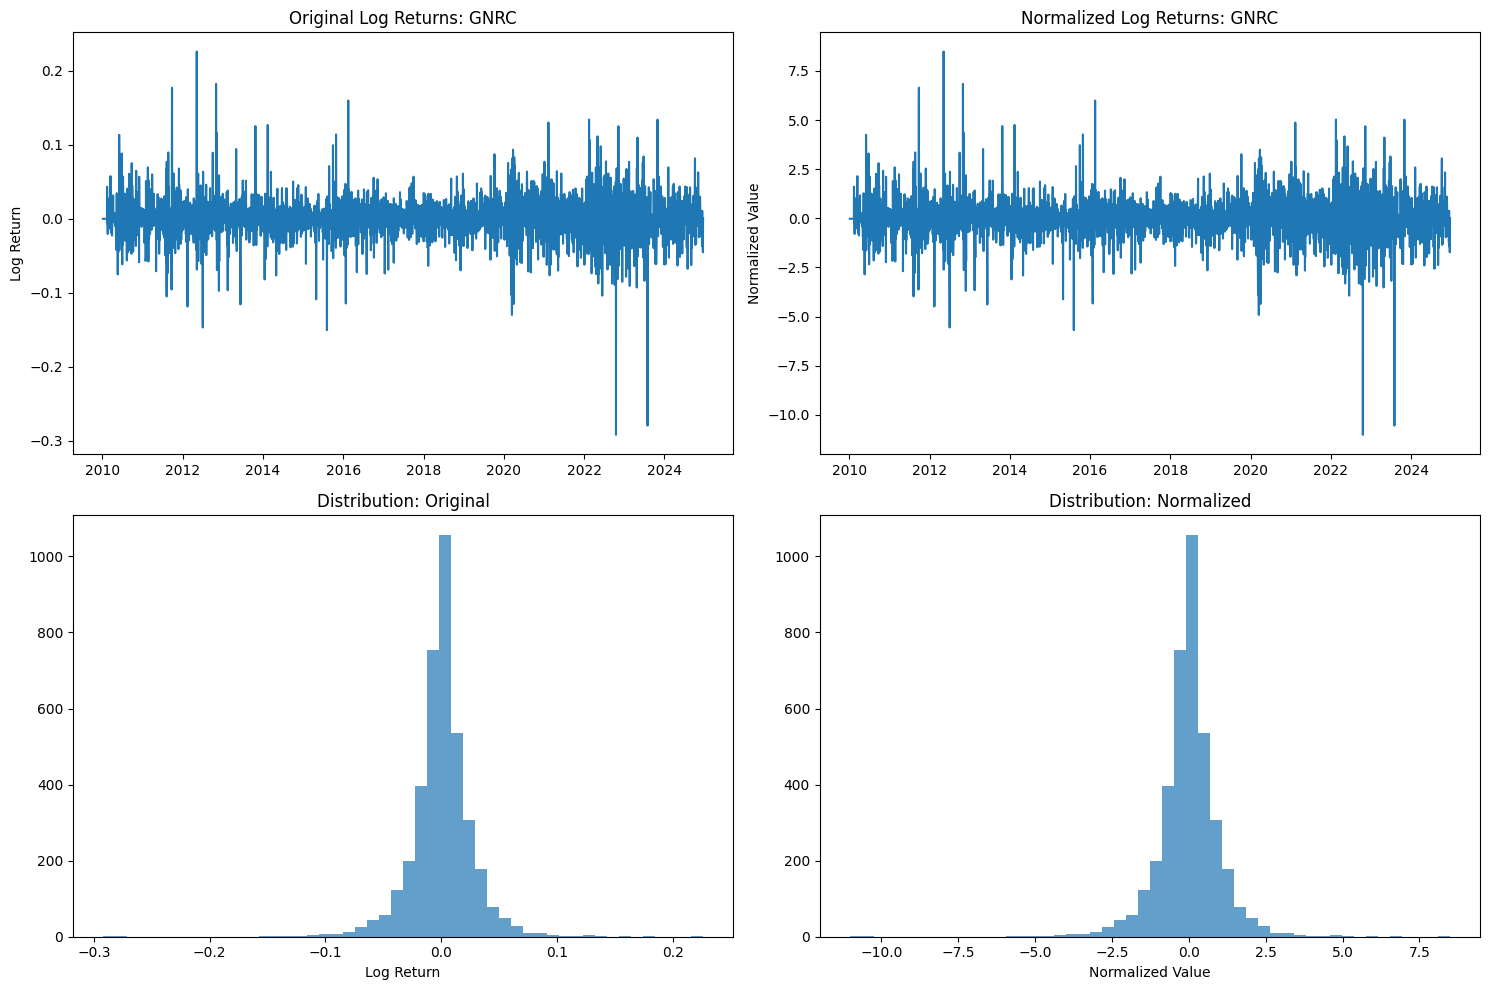

In [19]:
# Normalize log returns for autoencoder training
scaler = StandardScaler()
log_returns_scaled = scaler.fit_transform(log_returns)

log_returns_normalized = pd.DataFrame(
    log_returns_scaled,
    index=log_returns.index,
    columns=log_returns.columns
)

print("Normalized log returns:", log_returns_normalized.shape)
print("Mean (should be ~0):", log_returns_normalized.mean().mean())
print("Std (should be ~1):", log_returns_normalized.std().mean())

# Visualize normalization effect
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sample_ticker = selected_tickers[0]

axes[0, 0].plot(log_returns.index, log_returns[sample_ticker])
axes[0, 0].set_title('Original Log Returns: ' + sample_ticker)
axes[0, 0].set_ylabel('Log Return')

axes[0, 1].plot(log_returns_normalized.index, log_returns_normalized[sample_ticker])
axes[0, 1].set_title('Normalized Log Returns: ' + sample_ticker)
axes[0, 1].set_ylabel('Normalized Value')

axes[1, 0].hist(log_returns[sample_ticker].dropna(), bins=50, alpha=0.7)
axes[1, 0].set_title('Distribution: Original')
axes[1, 0].set_xlabel('Log Return')

axes[1, 1].hist(log_returns_normalized[sample_ticker].dropna(), bins=50, alpha=0.7)
axes[1, 1].set_title('Distribution: Normalized')
axes[1, 1].set_xlabel('Normalized Value')

plt.tight_layout()
plt.show()


## Prepare Data for Autoencoder


In [20]:
# Prepare data for autoencoder training (HYBRID FEATURES: returns + price-level + rolling stats + market corr)
window = 20
print("Building hybrid features (returns + prices + rolling stats + market corr)...")

log_prices = np.log(prices_subset).fillna(method='ffill').fillna(method='bfill')
returns = log_returns.copy()  # already computed earlier

# market proxy = cross-sectional mean return (helps capture common mode)
market_return = returns.mean(axis=1)

feature_vectors = []
feature_names = ['ret','logprice','roll_ret_mean','roll_ret_std','mom_20','corr_market']

for ticker in selected_tickers:
    # Align all series on the same time index to avoid length mismatches
    common_idx = returns.index.intersection(log_prices.index)
    r = returns[ticker].reindex(common_idx).fillna(0)
    p = log_prices[ticker].reindex(common_idx).fillna(method='ffill').fillna(method='bfill')
    mr = market_return.reindex(common_idx).fillna(0)

    roll_mean = r.rolling(window).mean().fillna(0)
    roll_std = r.rolling(window).std().fillna(0)
    mom = p.pct_change(periods=window).fillna(0)  # momentum over window
    corr_market = r.rolling(window).corr(mr).fillna(0)
    
    # Stack per-time features (n_time_steps, n_features)
    feats = np.vstack([
        r.values,
        p.values,
        roll_mean.values,
        roll_std.values,
        mom.values,
        corr_market.values
    ]).T

    # Standardize per-feature across time for this ticker
    feat_scaler = StandardScaler()
    feats_scaled = feat_scaler.fit_transform(feats)
    # Flatten to single vector for this stock
    feature_vectors.append(feats_scaled.flatten())

X_hybrid = np.vstack(feature_vectors)  # shape: (n_stocks, n_time * n_features)
print("Hybrid raw shape (n_stocks, time*n_features):", X_hybrid.shape)

# Dimensionality reduction before autoencoder to reduce memory & speed up training
from sklearn.decomposition import PCA
max_pca_components = min(300, X_hybrid.shape[1] - 1)
print("Applying PCA to reduce dimensionality to:", max_pca_components)
pca_pre = PCA(n_components=max_pca_components, random_state=42)
X_reduced = pca_pre.fit_transform(X_hybrid)
print("After PCA shape (n_stocks, n_components):", X_reduced.shape)

# Final input for autoencoder: X = X_reduced
X = X_reduced.copy()

print("Prepared data for autoencoder (hybrid):", X.shape)
print("Each row represents one stock (hybrid features compressed by PCA).")



Building hybrid features (returns + prices + rolling stats + market corr)...
Hybrid raw shape (n_stocks, time*n_features): (432, 23424)
Applying PCA to reduce dimensionality to: 300
After PCA shape (n_stocks, n_components): (432, 300)
Prepared data for autoencoder (hybrid): (432, 300)
Each row represents one stock (hybrid features compressed by PCA).


## Build Autoencoder Model


In [21]:
# Build autoencoder architecture
input_dim = X.shape[1]
encoding_dim = 10

# Encoder
input_layer = keras.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(32, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded)

# Autoencoder model
autoencoder = keras.Model(input_layer, decoded)

# Encoder model (to get embeddings)
encoder = keras.Model(input_layer, encoded)

# Compile
autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Autoencoder model built")
print("\nModel architecture:")
autoencoder.summary()

print("\nModel configuration:")
print("Input dimension:", input_dim)
print("Encoding dimension:", encoding_dim)
print("Compression ratio:", input_dim/encoding_dim)


Autoencoder model built

Model architecture:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 300)            │        19,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,638 (170.46 KB)

 Trainable params: 43,638 (170.46 KB)

 Non-trainable params: 0 (0.00 B)


Model configuration:
Input dimension: 300
Encoding dimension: 10
Compression ratio: 30.0


## Train Autoencoder


Training autoencoder...
Epochs: 100
Batch size: 32
Validation split: 0.2
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 42.0335 - mae: 4.3304 - val_loss: 43.9152 - val_mae: 4.2848 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 41.7693 - mae: 4.3120 - val_loss: 43.8658 - val_mae: 4.2820 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 41.6813 - mae: 4.3086 - val_loss: 43.8548 - val_mae: 4.2847 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 41.5278 - mae: 4.3050 - val_loss: 43.8359 - val_mae: 4.2922 - learning_rate: 0.0010
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 41.2638 - mae: 4.3007 - val_loss: 43.7636 - val_mae: 4.3019 - learning_rate: 0.0010
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40.8458 - mae: 4.2945 - val_loss: 43.5273 - val_mae: 4.3060 - learning_rate: 0.0010
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40.2881 - 

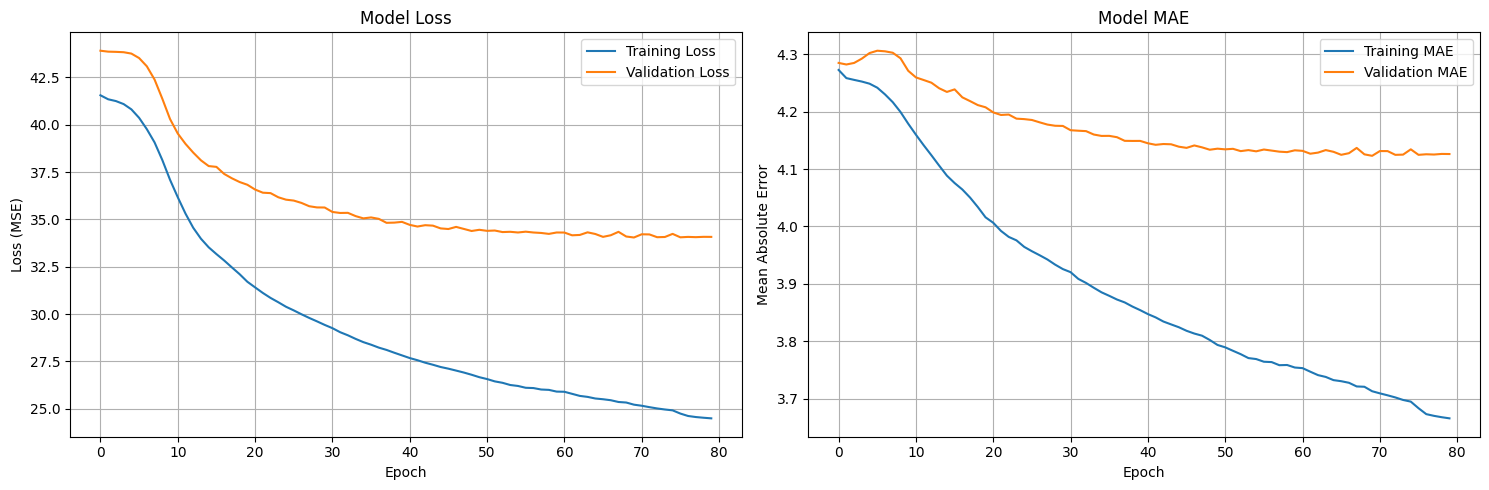

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Reconstruction quality:
Mean reconstruction error: 26.783021041325338
Best reconstructed stock: CMS
Worst reconstructed stock: KDP


In [22]:
# Train autoencoder
epochs = 100
batch_size = 32
validation_split = 0.2

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

print("Training autoencoder...")
print("Epochs:", epochs)
print("Batch size:", batch_size)
print("Validation split:", validation_split)

history = autoencoder.fit(
    X, X,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\nTraining completed!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate reconstruction
reconstruction = autoencoder.predict(X)
reconstruction_error = np.mean((X - reconstruction) ** 2, axis=1)

print("\nReconstruction quality:")
print("Mean reconstruction error:", reconstruction_error.mean())
print("Best reconstructed stock:", selected_tickers[reconstruction_error.argmin()])
print("Worst reconstructed stock:", selected_tickers[reconstruction_error.argmax()])


## Extract Embeddings


In [23]:
# Extract embeddings (encoded representations) for each stock
embeddings = encoder.predict(X)

print("Extracted embeddings:", embeddings.shape)
print("Shape: (n_stocks=" + str(embeddings.shape[0]) + ", embedding_dim=" + str(embeddings.shape[1]) + ")")

# Create DataFrame for easier manipulation
embeddings_df = pd.DataFrame(
    embeddings,
    index=selected_tickers,
    columns=['emb_' + str(i) for i in range(embeddings.shape[1])]
)

print("\nEmbeddings DataFrame:")
display(embeddings_df.head(10))

# Save embeddings
embeddings_df.to_csv('./dataset/autoencoder_embeddings.csv')
print("\nSaved embeddings to: ./dataset/autoencoder_embeddings.csv")


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Extracted embeddings: (432, 10)
Shape: (n_stocks=432, embedding_dim=10)

Embeddings DataFrame:


,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9
GNRC,0.000000,28.728764,0.208743,29.655743,110.557838,0.000000,53.588196,11.824697,68.469696,13.405464
CHTR,0.000000,84.095299,0.380008,0.589865,15.730155,0.000000,0.000000,0.000000,9.330864,48.737816
MTCH,6.794432,103.837029,4.375479,0.000000,33.197891,0.000000,41.048332,0.000000,14.680920,53.885887
NDAQ,28.231636,31.523176,0.000000,7.982079,40.458591,6.475490,9.367681,0.187449,15.574221,1.011853
WFC,1.517727,57.526653,60.480350,5.256815,11.673113,2.897239,0.082890,57.888210,95.978210,0.000000
WM,37.005295,10.809051,0.000000,32.569164,25.168549,0.000000,0.000000,0.000000,0.000000,49.575096
WELL,0.000000,18.853868,28.349344,52.908150,61.865246,0.000000,3.873528,0.000000,126.703056,52.361336
WMB,42.801025,42.570950,109.617119,21.047979,3.499894,0.000000,0.000000,24.988592,66.693649,0.000000
MU,6.329967,87.659843,28.046473,48.100769,46.315567,19.179033,93.724693,31.979723,58.340988,0.000000
NDSN,33.230904,48.700935,29.160738,34.370705,14.318399,7.551636,0.000000,30.609573,16.987663,4.816705



Saved embeddings to: ./dataset/autoencoder_embeddings.csv


## KMeans Clustering


In [24]:
# Determine optimal number of clusters using silhouette score
cluster_range = range(4, 7)
silhouette_scores = []

print("Finding optimal number of clusters...")

for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    silhouette_avg = silhouette_score(embeddings, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print("n_clusters=" + str(n_clusters) + ": silhouette_score=" + str(silhouette_avg))

# Select best number of clusters
optimal_clusters = cluster_range[np.argmax(silhouette_scores)]
print("\nOptimal number of clusters:", optimal_clusters)

# Final clustering with optimal number
kmeans_final = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(embeddings)

# Add cluster labels to embeddings DataFrame
embeddings_df['cluster'] = cluster_labels

# Show cluster distribution
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print("\nCluster distribution:")
for cluster_id, count in cluster_counts.items():
    stocks_in_cluster = embeddings_df[embeddings_df['cluster'] == cluster_id].index.tolist()
    print("Cluster " + str(cluster_id) + ":", count, "stocks")
    print("  " + ', '.join(stocks_in_cluster[:10]) + ('...' if len(stocks_in_cluster) > 10 else ''))

# Show sectors in each cluster
print("\nSector distribution within clusters:")
for cluster_id in range(optimal_clusters):
    stocks_in_cluster = embeddings_df[embeddings_df['cluster'] == cluster_id].index.tolist()
    sectors_in_cluster = [stock_sectors.get(t, 'Unknown') for t in stocks_in_cluster]
    sector_counts = pd.Series(sectors_in_cluster).value_counts()
    print("\nCluster " + str(cluster_id) + " (" + str(len(stocks_in_cluster)) + " stocks):")
    for sector, count in sector_counts.items():
        print("  " + sector + ":", count)


Finding optimal number of clusters...
n_clusters=4: silhouette_score=0.18939781188964844
n_clusters=5: silhouette_score=0.20367705821990967
n_clusters=6: silhouette_score=0.20266826450824738

Optimal number of clusters: 5

Cluster distribution:
Cluster 0: 111 stocks
  WFC, WMB, MTB, MS, TSN, OMC, OKE, ODFL, WAB, NUE...
Cluster 1: 71 stocks
  NEE, WMT, MRK, WEC, VZ, NVR, NI, MOH, MO, LLY...
Cluster 2: 148 stocks
  CHTR, NDAQ, WM, NDSN, MTD, TROW, MSI, MSCI, WAT, NSC...
Cluster 3: 47 stocks
  WELL, MOS, O, WBA, WBD, WDC, XOM, LVS, LUV, WYNN...
Cluster 4: 55 stocks
  GNRC, MTCH, MU, MSFT, MPWR, NFLX, NEM, ON, NVDA, NTAP...

Sector distribution within clusters:

Cluster 0 (111 stocks):
  Financials: 38
  Consumer Discretionary: 20
  Industrials: 19
  Materials: 11
  Energy: 10
  Information Technology: 4
  Consumer Staples: 3
  Unknown: 3
  Communication Services: 2
  Real Estate: 1

Cluster 1 (71 stocks):
  Utilities: 26
  Consumer Staples: 20
  Healthcare: 12
  Real Estate: 7
  Consumer 

## PCA Visualization


PCA transformation completed
Explained variance ratio: 0.55596584
PC1: 0.3285537
PC2: 0.22741212


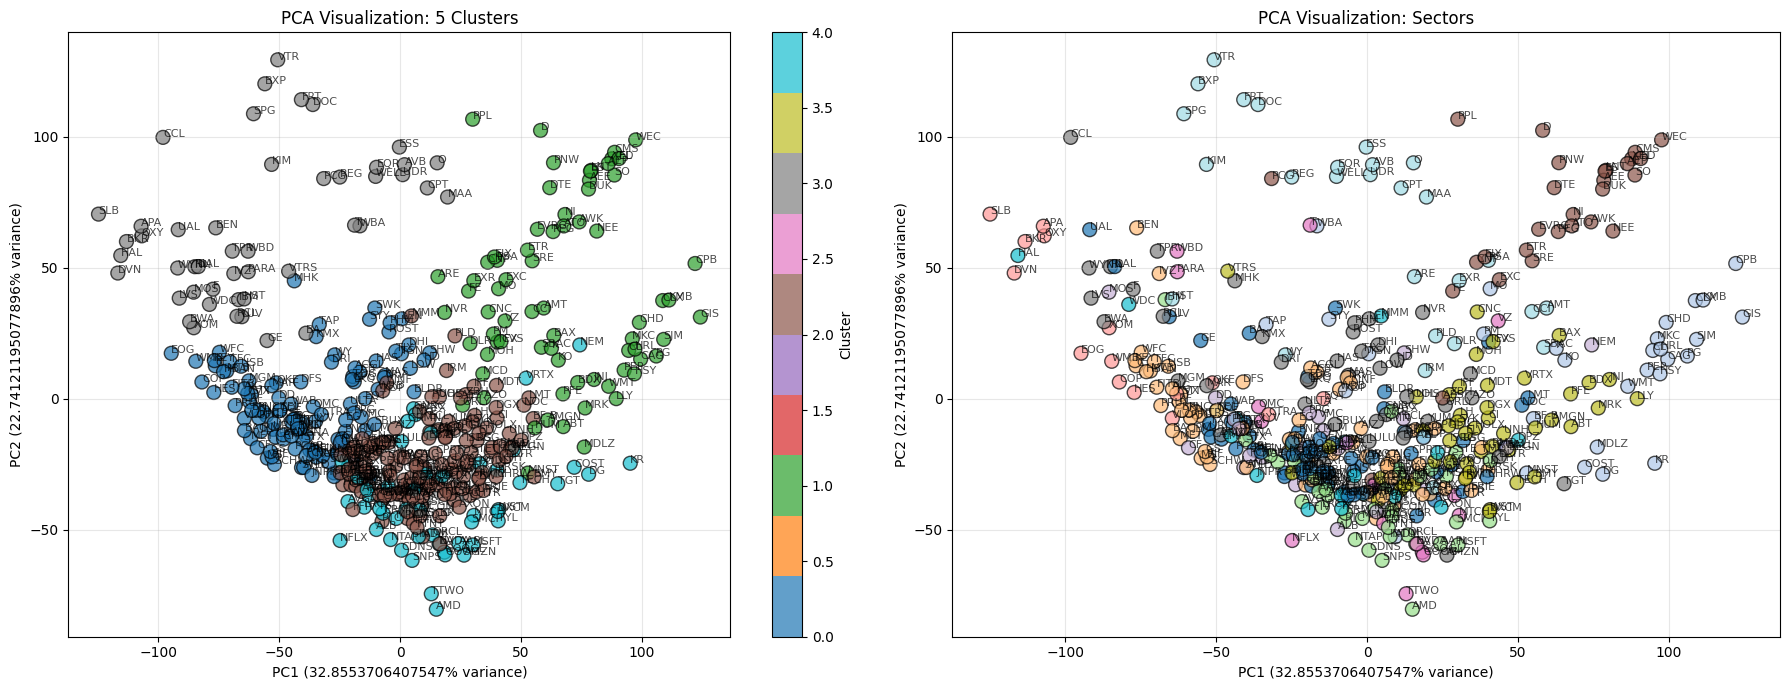


Saved PCA results to: ./dataset/pca_embeddings.csv


In [25]:
# Reduce embeddings to 2D using PCA for visualization
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

print("PCA transformation completed")
print("Explained variance ratio:", pca.explained_variance_ratio_.sum())
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Clusters
scatter1 = axes[0].scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=cluster_labels, 
    cmap='tab10',
    s=100,
    alpha=0.7,
    edgecolors='black'
)

for i, ticker in enumerate(selected_tickers):
    axes[0].annotate(ticker, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                    fontsize=8, alpha=0.7)

axes[0].set_title('PCA Visualization: ' + str(optimal_clusters) + ' Clusters')
axes[0].set_xlabel('PC1 (' + str(pca.explained_variance_ratio_[0]*100) + '% variance)')
axes[0].set_ylabel('PC2 (' + str(pca.explained_variance_ratio_[1]*100) + '% variance)')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Sectors
sector_to_color = {sector: i for i, sector in enumerate(set(stock_sectors.values()))}
sector_colors = [sector_to_color.get(stock_sectors.get(t, 'Unknown'), -1) 
                for t in selected_tickers]

scatter2 = axes[1].scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=sector_colors, 
    cmap='tab20',
    s=100,
    alpha=0.7,
    edgecolors='black'
)

for i, ticker in enumerate(selected_tickers):
    axes[1].annotate(ticker, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                    fontsize=8, alpha=0.7)

axes[1].set_title('PCA Visualization: Sectors')
axes[1].set_xlabel('PC1 (' + str(pca.explained_variance_ratio_[0]*100) + '% variance)')
axes[1].set_ylabel('PC2 (' + str(pca.explained_variance_ratio_[1]*100) + '% variance)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save PCA results
pca_df = pd.DataFrame(
    embeddings_2d,
    index=selected_tickers,
    columns=['PC1', 'PC2']
)
pca_df['cluster'] = cluster_labels
pca_df.to_csv('./dataset/pca_embeddings.csv')
print("\nSaved PCA results to: ./dataset/pca_embeddings.csv")


## t-SNE Visualization


Computing t-SNE embedding (this may take a few minutes)...
t-SNE transformation completed


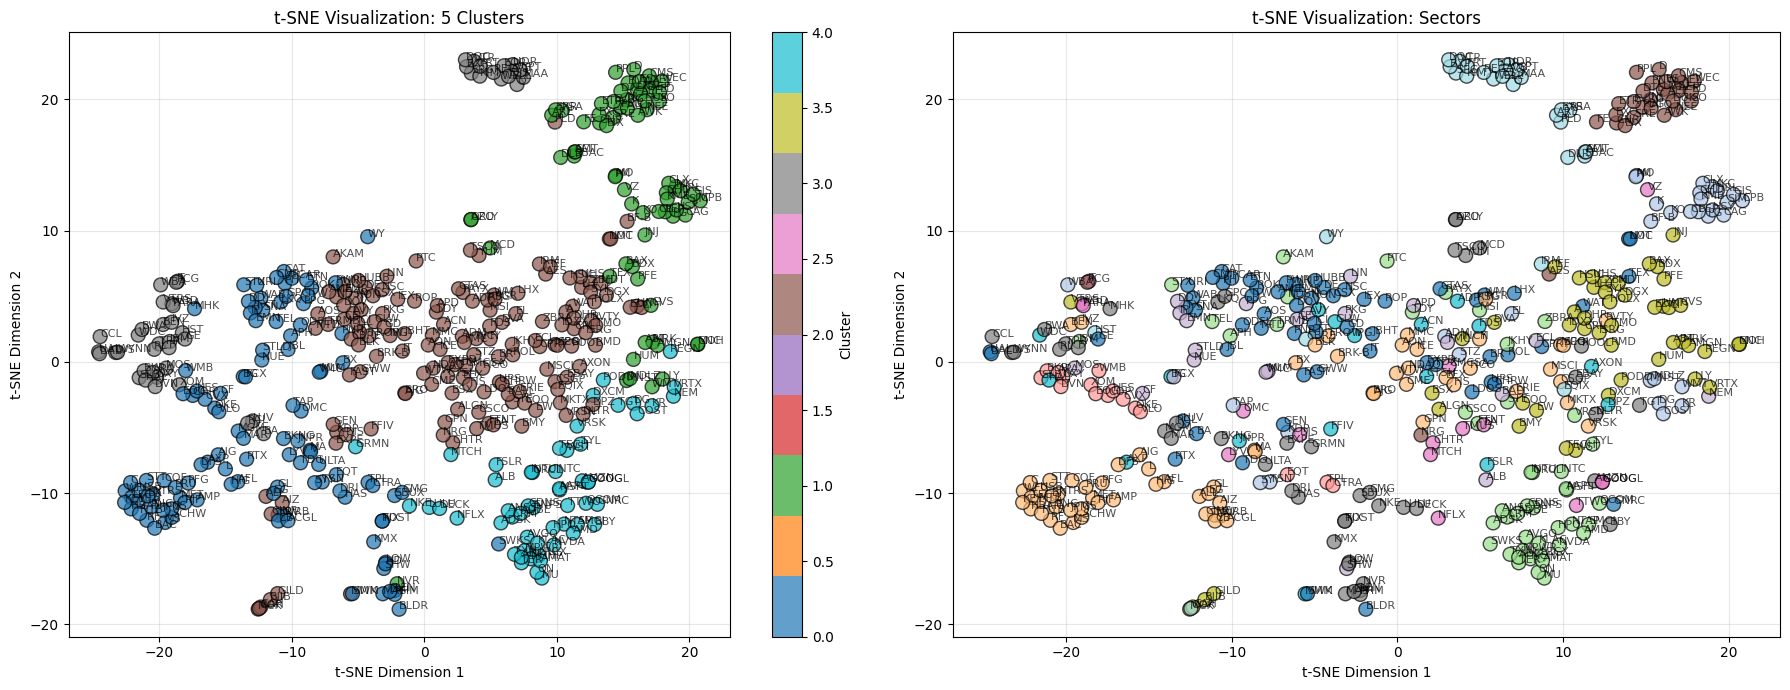


Saved t-SNE results to: ./dataset/tsne_embeddings.csv


In [26]:
# Use t-SNE for non-linear dimensionality reduction
print("Computing t-SNE embedding (this may take a few minutes)...")

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(selected_tickers)-1))
embeddings_tsne = tsne.fit_transform(embeddings)

print("t-SNE transformation completed")

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Clusters
scatter1 = axes[0].scatter(
    embeddings_tsne[:, 0], 
    embeddings_tsne[:, 1], 
    c=cluster_labels, 
    cmap='tab10',
    s=100,
    alpha=0.7,
    edgecolors='black'
)

for i, ticker in enumerate(selected_tickers):
    axes[0].annotate(ticker, (embeddings_tsne[i, 0], embeddings_tsne[i, 1]), 
                    fontsize=8, alpha=0.7)

axes[0].set_title('t-SNE Visualization: ' + str(optimal_clusters) + ' Clusters')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: Sectors
scatter2 = axes[1].scatter(
    embeddings_tsne[:, 0], 
    embeddings_tsne[:, 1], 
    c=sector_colors, 
    cmap='tab20',
    s=100,
    alpha=0.7,
    edgecolors='black'
)

for i, ticker in enumerate(selected_tickers):
    axes[1].annotate(ticker, (embeddings_tsne[i, 0], embeddings_tsne[i, 1]), 
                    fontsize=8, alpha=0.7)

axes[1].set_title('t-SNE Visualization: Sectors')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save t-SNE results
tsne_df = pd.DataFrame(
    embeddings_tsne,
    index=selected_tickers,
    columns=['TSNE1', 'TSNE2']
)
tsne_df['cluster'] = cluster_labels
tsne_df.to_csv('./dataset/tsne_embeddings.csv')
print("\nSaved t-SNE results to: ./dataset/tsne_embeddings.csv")


## Select Candidate Pairs Within Clusters


In [27]:
# Select candidate pairs from within clusters
import itertools

cluster_pairs = []
pair_distances = []

for cluster_id in range(optimal_clusters):
    stocks_in_cluster = embeddings_df[embeddings_df['cluster'] == cluster_id].index.tolist()
    
    if len(stocks_in_cluster) >= 2:
        pairs_in_cluster = list(itertools.combinations(stocks_in_cluster, 2))
        
        for ticker1, ticker2 in pairs_in_cluster:
            emb1 = embeddings_df.loc[ticker1].drop('cluster').values
            emb2 = embeddings_df.loc[ticker2].drop('cluster').values
            distance = np.linalg.norm(emb1 - emb2)
            
            cluster_pairs.append({
                'ticker1': ticker1,
                'ticker2': ticker2,
                'cluster': cluster_id,
                'embedding_distance': distance,
                'sector1': stock_sectors.get(ticker1, 'Unknown'),
                'sector2': stock_sectors.get(ticker2, 'Unknown'),
                'same_sector': stock_sectors.get(ticker1, 'Unknown') == stock_sectors.get(ticker2, 'Unknown')
            })
            pair_distances.append(distance)

cluster_pairs_df = pd.DataFrame(cluster_pairs)

# Sort to prioritize same-sector pairs, then by embedding distance
# Convert same_sector to numeric for sorting (False=0, True=1), then negate so True comes first
cluster_pairs_df['same_sector_sort'] = cluster_pairs_df['same_sector'].astype(int)
cluster_pairs_df = cluster_pairs_df.sort_values(['same_sector_sort', 'embedding_distance'], ascending=[False, True])
cluster_pairs_df = cluster_pairs_df.drop('same_sector_sort', axis=1)

print("Found", len(cluster_pairs_df), "candidate pairs within clusters")
print("\nPair statistics:")
print("Total pairs:", len(cluster_pairs_df))
print("Same-sector pairs:", cluster_pairs_df['same_sector'].sum(), "(" + str(cluster_pairs_df['same_sector'].mean()*100) + "%)")
print("Average embedding distance:", cluster_pairs_df['embedding_distance'].mean())

# Select top-N candidate pairs (prioritizing same-sector pairs)
N = 20
top_pairs = cluster_pairs_df.head(N)

print("\nTop", N, "candidate pairs (prioritizing same-sector pairs):")

for idx, row in top_pairs.iterrows():
    same_sector_marker = "Same sector" if row['same_sector'] else "Cross sector"
    print("Cluster " + str(int(row['cluster'])) + ": " + row['ticker1'] + " (" + row['sector1'] + ")  <->  " + 
          row['ticker2'] + " (" + row['sector2'] + ")")
    print("  " + same_sector_marker + ", Embedding distance: " + str(row['embedding_distance']))
    print()

# Show top same-sector pairs separately
same_sector_pairs = cluster_pairs_df[cluster_pairs_df['same_sector'] == True].head(N)
if len(same_sector_pairs) > 0:
    print("\nTop", min(N, len(same_sector_pairs)), "same-sector pairs within clusters:")
    for idx, row in same_sector_pairs.iterrows():
        print("Cluster " + str(int(row['cluster'])) + ": " + row['ticker1'] + " (" + row['sector1'] + ")  <->  " + 
              row['ticker2'] + " (" + row['sector2'] + ")")
        print("  Embedding distance: " + str(row['embedding_distance']))
        print()

# Save candidate pairs
cluster_pairs_df.to_csv('./dataset/cluster_candidate_pairs.csv', index=False)
print("Saved candidate pairs to: ./dataset/cluster_candidate_pairs.csv")

# Cluster-wise summary
print("\nPairs per cluster:")
for cluster_id in range(optimal_clusters):
    cluster_pair_count = len(cluster_pairs_df[cluster_pairs_df['cluster'] == cluster_id])
    if cluster_pair_count > 0:
        same_sector_count = cluster_pairs_df[
            (cluster_pairs_df['cluster'] == cluster_id) & 
            (cluster_pairs_df['same_sector'] == True)
        ].shape[0]
        print("Cluster " + str(cluster_id) + ": " + str(cluster_pair_count) + " pairs (" + 
              str(same_sector_count) + " same-sector)")


Found 22034 candidate pairs within clusters

Pair statistics:
Total pairs: 22034
Same-sector pairs: 4042 (18.344376872106743%)
Average embedding distance: 74.14609768131729

Top 20 candidate pairs (prioritizing same-sector pairs):
Cluster 4: GOOGL (Communication Services)  <->  GOOG (Communication Services)
  Same sector, Embedding distance: 2.006649633899911

Cluster 2: NOC (Industrials)  <->  LMT (Industrials)
  Same sector, Embedding distance: 5.752193464189989

Cluster 1: CMS (Utilities)  <->  AEP (Utilities)
  Same sector, Embedding distance: 6.582416531365829

Cluster 3: UDR (Real Estate)  <->  AVB (Real Estate)
  Same sector, Embedding distance: 7.43803742296291

Cluster 1: XEL (Utilities)  <->  CMS (Utilities)
  Same sector, Embedding distance: 7.699775104283387

Cluster 1: NI (Utilities)  <->  ATO (Utilities)
  Same sector, Embedding distance: 8.185269427069468

Cluster 2: MCO (Financials)  <->  SPGI (Financials)
  Same sector, Embedding distance: 8.65042773283104

Cluster 1: 

## Summary and Results


In [28]:
print("\nCompleted ML Discovery (Autoencoder + Clustering)")
print("\nResults:")
print("  Stocks analyzed:", len(selected_tickers))
print("  Embedding dimension:", embeddings.shape[1])
print("  Optimal clusters:", optimal_clusters)
print("  Candidate pairs found:", len(cluster_pairs_df))
print("  Same-sector pairs:", cluster_pairs_df['same_sector'].sum())


# Create cluster summary
cluster_summary = []
for cluster_id in range(optimal_clusters):
    stocks_in_cluster = embeddings_df[embeddings_df['cluster'] == cluster_id].index.tolist()
    sectors = [stock_sectors.get(t, 'Unknown') for t in stocks_in_cluster]
    cluster_summary.append({
        'cluster': cluster_id,
        'n_stocks': len(stocks_in_cluster),
        'stocks': ', '.join(stocks_in_cluster),
        'dominant_sector': pd.Series(sectors).mode()[0] if len(sectors) > 0 else 'Unknown',
        'sectors': ', '.join(set(sectors))
    })

cluster_summary_df = pd.DataFrame(cluster_summary)
display(cluster_summary_df)



Completed ML Discovery (Autoencoder + Clustering)

Results:
  Stocks analyzed: 432
  Embedding dimension: 10
  Optimal clusters: 5
  Candidate pairs found: 22034
  Same-sector pairs: 4042


,cluster,n_stocks,stocks,dominant_sector,sectors
0,0,111,"WFC, WMB, MTB, MS, TSN, OMC, OKE, ODFL, WAB, N...",Financials,"Industrials, Consumer Staples, Financials, Inf..."
1,1,71,"NEE, WMT, MRK, WEC, VZ, NVR, NI, MOH, MO, LLY,...",Utilities,"Industrials, Consumer Staples, Utilities, Comm..."
2,2,148,"CHTR, NDAQ, WM, NDSN, MTD, TROW, MSI, MSCI, WA...",Industrials,"Industrials, Consumer Staples, Financials, Inf..."
3,3,47,"WELL, MOS, O, WBA, WBD, WDC, XOM, LVS, LUV, WY...",Real Estate,"Industrials, Consumer Staples, Financials, Inf..."
4,4,55,"GNRC, MTCH, MU, MSFT, MPWR, NFLX, NEM, ON, NVD...",Information Technology,"Industrials, Consumer Staples, Financials, Inf..."


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Stage 4 candidate pairs
try:
    cluster_pairs_df = pd.read_csv('./dataset/cluster_candidate_pairs.csv')
    print("✅ Loaded Stage 4 candidate pairs")
    print(f"Total pairs: {len(cluster_pairs_df)}")
except FileNotFoundError:
    print("❌ File not found. Ensure stage4_ml_discovery.ipynb has been run.")
    cluster_pairs_df = None

# Check if AJG-CDNS pair exists in Stage 4 results
if cluster_pairs_df is not None:
    # Check both orderings (AJG-CDNS and CDNS-AJG)
    ajg_cdns = cluster_pairs_df[
        ((cluster_pairs_df['ticker1'] == 'AJG') & (cluster_pairs_df['ticker2'] == 'CDNS')) |
        ((cluster_pairs_df['ticker1'] == 'CDNS') & (cluster_pairs_df['ticker2'] == 'AJG'))
    ]
    
    if len(ajg_cdns) > 0:
        print("\n✅ FOUND: AJG-CDNS pair in Stage 4 clustering results!")
        print(ajg_cdns.to_string())
        pair_found_in_stage4 = True
    else:
        print("\n❌ NOT FOUND: AJG-CDNS pair NOT in Stage 4 clustering results")
        print("   (Baseline Stage 3 found it as top cointegrated pair, but ML Stage 4 did not cluster them together)")
        pair_found_in_stage4 = False
        
        # Show closest pairs to AJG and CDNS in clustering
        print("\n   Closest pairs to AJG in Stage 4:")
        ajg_pairs = cluster_pairs_df[
            (cluster_pairs_df['ticker1'] == 'AJG') | (cluster_pairs_df['ticker2'] == 'AJG')
        ].nsmallest(3, 'embedding_distance')
        display(ajg_pairs[['ticker1', 'ticker2', 'cluster', 'embedding_distance', 'same_sector']])
        
        print("\n   Closest pairs to CDNS in Stage 4:")
        cdns_pairs = cluster_pairs_df[
            (cluster_pairs_df['ticker1'] == 'CDNS') | (cluster_pairs_df['ticker2'] == 'CDNS')
        ].nsmallest(3, 'embedding_distance')
        display(cdns_pairs[['ticker1', 'ticker2', 'cluster', 'embedding_distance', 'same_sector']])

✅ Loaded Stage 4 candidate pairs
Total pairs: 22034

❌ NOT FOUND: AJG-CDNS pair NOT in Stage 4 clustering results
   (Baseline Stage 3 found it as top cointegrated pair, but ML Stage 4 did not cluster them together)

   Closest pairs to AJG in Stage 4:


,ticker1,ticker2,cluster,embedding_distance,same_sector
290,BRO,AJG,2,27.099996,True
698,WTW,AJG,2,37.281369,True
970,AJG,AON,2,42.343938,True



   Closest pairs to CDNS in Stage 4:


,ticker1,ticker2,cluster,embedding_distance,same_sector
50,SNPS,CDNS,4,15.391756,True
725,CDNS,ANSS,4,38.064023,True
814,CDNS,ADBE,4,39.602919,True


## Compare Engle–Granger and Clustering Pairs



In [31]:
# Compare Engle–Granger cointegration pairs with Stage 4 clustering pairs
import ast

# Load clustering candidate pairs (Stage 4)
try:
    cluster_pairs_df = pd.read_csv('./dataset/cluster_candidate_pairs.csv')
    print("Loaded Stage 4 candidate pairs:", len(cluster_pairs_df))
except FileNotFoundError:
    print("cluster_candidate_pairs.csv not found. Run the clustering section first.")
    cluster_pairs_df = None

# Load Engle–Granger cointegration results (Stage 3)
try:
    coint_results = pd.read_csv('./dataset/cointegration_results.csv')
    print("Loaded Engle–Granger cointegration results:", len(coint_results))
except FileNotFoundError:
    print("cointegration_results.csv not found. Run pair-trading-stage3.ipynb first.")
    coint_results = None

if cluster_pairs_df is not None and coint_results is not None:
    # Ensure we have explicit ticker1/ticker2 columns in cointegration results
    if 'ticker1' not in coint_results.columns or 'ticker2' not in coint_results.columns:
        if 'pair' in coint_results.columns:
            def parse_pair(x):
                try:
                    # Try literal eval like "('AAPL','MSFT')"
                    val = ast.literal_eval(str(x))
                    if isinstance(val, (list, tuple)) and len(val) >= 2:
                        return str(val[0]), str(val[1])
                except Exception:
                    pass
                # Fallback: split by comma
                s = str(x).strip().strip('()[]')
                parts = [p.strip(" '\"") for p in s.split(',') if p.strip()]
                if len(parts) >= 2:
                    return parts[0], parts[1]
                return None, None
            coint_results[['ticker1','ticker2']] = coint_results['pair'].apply(
                lambda v: pd.Series(parse_pair(v))
            )
        else:
            raise ValueError("cointegration_results.csv is missing both 'ticker1','ticker2' and 'pair' columns.")

    # Drop any rows where parsing failed
    coint_results = coint_results.dropna(subset=['ticker1','ticker2']).copy()

    # Build normalized pair keys (order-insensitive) for both sources
    def make_pair_key(t1, t2):
        return '::'.join(sorted([str(t1), str(t2)]))

    coint_results['pair_key'] = coint_results.apply(
        lambda row: make_pair_key(row['ticker1'], row['ticker2']), axis=1
    )

    if not {'ticker1','ticker2'}.issubset(cluster_pairs_df.columns):
        raise ValueError("cluster_candidate_pairs.csv must contain 'ticker1' and 'ticker2' columns.")

    cluster_pairs_df['pair_key'] = cluster_pairs_df.apply(
        lambda row: make_pair_key(row['ticker1'], row['ticker2']), axis=1
    )

    # Compute intersections
    coint_keys   = set(coint_results['pair_key'])
    cluster_keys = set(cluster_pairs_df['pair_key'])
    common_keys  = coint_keys & cluster_keys

    print("\nSummary of overlap between Engle–Granger and clustering:")
    print("  Total EG pairs (Stage 3):", len(coint_keys))
    print("  Total clustering pairs (Stage 4):", len(cluster_keys))
    print("  Common pairs (intersection):", len(common_keys))
    if len(coint_keys) > 0:
        print("  Coverage of EG by clustering: {:.2f}%".format(100*len(common_keys)/len(coint_keys)))
    if len(cluster_keys) > 0:
        print("  Coverage of clustering by EG: {:.2f}%".format(100*len(common_keys)/len(cluster_keys)))

    # Build a DataFrame of common pairs with statistics from both sides
    common_coint   = coint_results[coint_results['pair_key'].isin(common_keys)].copy()
    common_cluster = cluster_pairs_df[cluster_pairs_df['pair_key'].isin(common_keys)].copy()

    # Merge on pair_key; keep useful columns from both
    common_pairs = common_cluster.merge(
        common_coint,
        on='pair_key',
        how='left',
        suffixes=('_cluster','_coint')
    )

    # Reorder / select key columns for readability
    cols = [
        'ticker1_cluster','ticker2_cluster',
        'cluster','embedding_distance','same_sector',
    ]
    if 'pvalue' in common_pairs.columns:
        cols += ['pvalue']
    if 'adf_stat' in common_pairs.columns:
        cols += ['adf_stat']
    cols = [c for c in cols if c in common_pairs.columns]

    display(common_pairs[cols].sort_values('embedding_distance'))

    # Save for later analysis / Stage 6
    out_path = './dataset/common_pairs_coint_vs_cluster.csv'
    common_pairs.to_csv(out_path, index=False)
    print(f"\nSaved common pairs to: {out_path}")
else:
    print("\nSkipping comparison because one of the required data sources is missing.")



Loaded Stage 4 candidate pairs: 22034
Loaded Engle–Granger cointegration results: 780

Summary of overlap between Engle–Granger and clustering:
  Total EG pairs (Stage 3): 780
  Total clustering pairs (Stage 4): 22034
  Common pairs (intersection): 240
  Coverage of EG by clustering: 30.77%
  Coverage of clustering by EG: 1.09%


,ticker1_cluster,ticker2_cluster,cluster,embedding_distance,same_sector,pvalue
0,DE,CSX,2,14.454017,True,0.472446
68,BR,ALGN,2,28.896514,False,0.931504
1,MRK,AMGN,1,30.599030,True,0.088251
69,CSX,BLK,2,32.240712,False,0.889740
70,BLK,ALGN,2,32.949460,False,0.984758
...,...,...,...,...,...,...
235,AMGN,GIS,1,125.495902,False,0.151193
236,CNC,HSY,1,146.637938,False,0.377666
237,CNC,KMB,1,150.514926,False,0.216452
238,CNC,HRL,1,162.264399,False,0.356427



Saved common pairs to: ./dataset/common_pairs_coint_vs_cluster.csv
